In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\archive (10)\weather_classification_data.csv")

In [14]:
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [5]:
df=data.copy()

In [6]:
from sklearn.preprocessing import OrdinalEncoder

In [7]:
df["Weather Type"].unique()

array(['Rainy', 'Cloudy', 'Sunny', 'Snowy'], dtype=object)

In [9]:
l=[['Rainy', 'Cloudy', 'Sunny', 'Snowy']]

In [10]:
on=OrdinalEncoder(categories=l)

In [12]:
df["Weather Type1"]=on.fit_transform(df[["Weather Type"]])

In [15]:
df.head(5)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Weather Type1
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,0.0
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,1.0
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,2.0
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,2.0
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,0.0


In [16]:
q1=df["Atmospheric Pressure"].quantile(0.25)
q3=df["Atmospheric Pressure"].quantile(0.75)

In [17]:
IQR=q3-q1

In [22]:
min=q1-(IQR*1.5)
max=q3+(IQR*1.5)

In [23]:
df.shape

(13200, 12)

In [25]:
df=df[(df["Atmospheric Pressure"]>min)&(df["Atmospheric Pressure"]<max)]

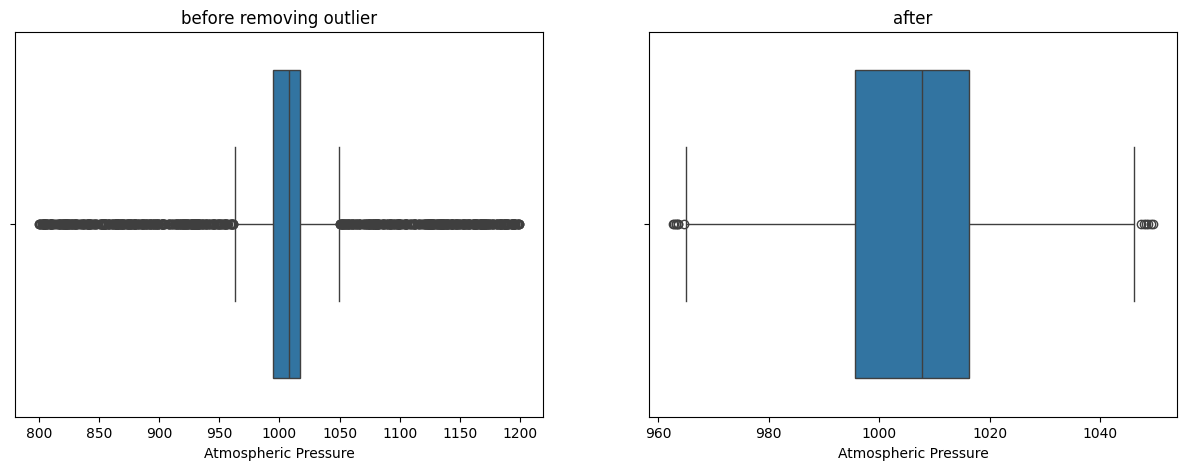

In [41]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(x=data["Atmospheric Pressure"],data=data)
plt.title("before removing outlier")

plt.subplot(1,2,2)
sns.boxplot(x=df["Atmospheric Pressure"],data=df)
plt.title("after")
plt.show()

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
x=df[["Temperature","Humidity","Wind Speed","Precipitation (%)","Atmospheric Pressure","UV Index","Visibility (km)"]]
y=df["Weather Type1"]

In [49]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.25)

In [60]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [51]:
gu=GaussianNB()
gu.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [52]:
gu.score(x_train,y_train),gu.score(x_test,y_test)

(0.924380704041721, 0.924079504724666)

In [57]:
dc=DecisionTreeClassifier(max_depth=5)
dc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [56]:
dc.score(x_train,y_train),dc.score(x_test,y_test)

(0.9584963059539331, 0.9475399152818508)

In [58]:
sv=SVC()
sv.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [59]:
sv.score(x_train,y_train),sv.score(x_test,y_test)

(0.8784224250325945, 0.8797653958944281)

In [61]:
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
knn.score(x_train,y_train),knn.score(x_test,y_test)

(0.952303346371143, 0.9387422613229065)

# ensembler

In [63]:
from sklearn.ensemble import VotingClassifier


In [70]:
vc=VotingClassifier(estimators=list)
vc.fit(x_train,y_train)

,estimators,"[('gu1', ...), ('dc1', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,priors,None
,var_smoothing,1e-09
,criterion,'gini'
,splitter,'best'
,max_depth,None


In [71]:
vc.score(x_train,y_train),vc.score(x_test,y_test)

(0.967296827466319, 0.9433040078201369)

In [76]:
pre={"gu":gu.predict(x_test),"dc":dc.predict(x_test),"knn":knn.predict(x_test),"vc":vc.predict(x_test),"exact":y_test}

In [77]:
hii=pd.DataFrame(pre)

In [80]:
hii.head(20)

,gu,dc,knn,vc,exact
11302,1.0,1.0,1.0,1.0,1.0
10406,0.0,0.0,0.0,0.0,0.0
8088,0.0,0.0,0.0,0.0,0.0
10485,1.0,0.0,0.0,0.0,0.0
11199,2.0,2.0,2.0,2.0,2.0
10290,2.0,2.0,2.0,2.0,2.0
5751,1.0,1.0,1.0,1.0,1.0
2185,3.0,3.0,3.0,3.0,3.0
9417,0.0,0.0,0.0,0.0,0.0
1158,3.0,3.0,3.0,3.0,3.0


In [81]:
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier

In [91]:
bc=BaggingClassifier(estimator=KNeighborsClassifier(),n_estimators=20)

In [92]:
bc.fit(x_train,y_train)

,estimator,KNeighborsClassifier()
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [93]:
bc.score(x_train,y_train),bc.score(x_test,y_test)

(0.9563233376792699, 0.9413489736070382)

In [115]:
rf=RandomForestClassifier(criterion='gini',n_estimators=30,max_depth=5)

In [116]:
rf.fit(x_train,y_train)

,n_estimators,30
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [118]:
rf.score(x_train,y_train)*100,rf.score(x_test,y_test)*100

(95.65406345067362, 95.2753339850114)